# Getting reach average shear stresses 
This is only using P3 by reverting to depth and calculating $\tau = g \rho s R$, but it is incorrect because it overestimates the discharge (and I am also using one cross-section to get tau). So, this notebook is incorrect, please see the shear stress reconstruction in the stress partitioning folder! 

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# import dicharge data and make date the index
discharge = pd.read_csv('la_jara_reconstructed_discharge_rsa.csv', index_col='timestamp', parse_dates=True)
depth_2022 = pd.read_csv('../water_depth/2022_depths.csv', index_col='Date_Time', parse_dates=True)
depth_2023 = pd.read_csv('../water_depth/2023_depths.csv', index_col='Date_Time', parse_dates=True)

# only keep data after 2022-07-01
discharge = discharge[discharge.index >= '2022-07-01']
depth_2022 = depth_2022[depth_2022.index >= '2022-07-01']
depth_2023 = depth_2023[depth_2023.index >= '2022-07-01']

### Convert Q to depth using rating curve

In [47]:
# breakpoint discharge
Q_break = 406.52 * (0.1968 ** 6.19) # to match 0.1968 m stage at break point between power law and linear equation

def discharge_to_stage(Q):
    if Q <= Q_break:
        return (Q / 406.52) ** (1 / 6.19)
    else:
        return (Q + 0.3) / 1.63

# apply to dataframe
discharge["stage_m"] = discharge["discharge"].apply(discharge_to_stage)
lajara = discharge.copy()

### Plot calculated depth vs measured in piezometer 3

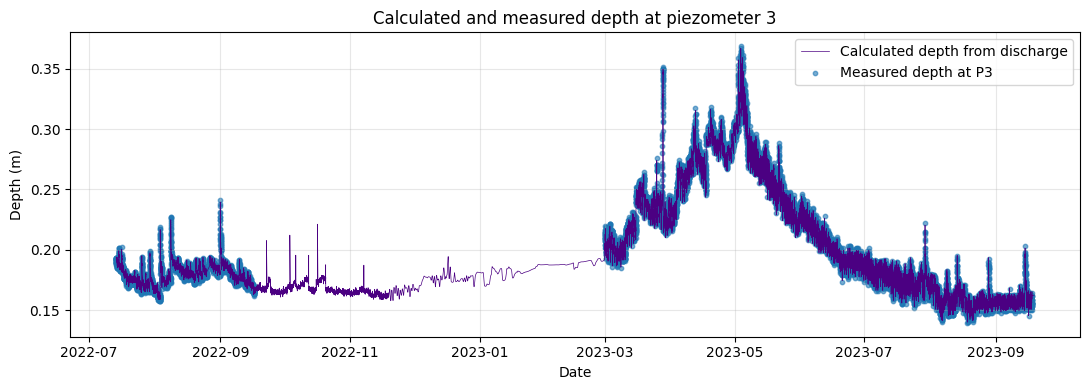

In [48]:
measured_p3 = (
    pd.concat([
        depth_2022[["P3"]].rename(columns={"P3": "measured_p3"}),
        depth_2023[["P3"]].rename(columns={"P3": "measured_p3"}),
    ])
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    discharge.index,
    discharge["stage_m"],
    color="indigo",
    linewidth=0.5,
    linestyle="-",
    label="Calculated depth from discharge",
)
ax.scatter(
    measured_p3.index,
    measured_p3["measured_p3"],
    color="tab:blue",
    s=10,
    alpha=0.6,
    label="Measured depth at P3",
)

ax.set_xlabel("Date")
ax.set_ylabel("Depth (m)")
ax.set_title("Calculated and measured depth at piezometer 3")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Scatter plot

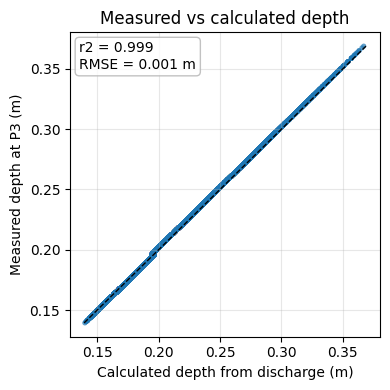

Number of overlapping dates used: 25416
R^2: 0.999
RMSE: 0.001 m


In [49]:
# keep only dates where both calculated and measured depth exist
compare_depth = discharge[["stage_m"]].join(measured_p3, how="inner").dropna()
# metrics (treat measured as truth and calculated as prediction)
y_true = compare_depth["measured_p3"]
y_pred = compare_depth["stage_m"]

rmse = ((y_true - y_pred) ** 2).mean() ** 0.5
ss_res = ((y_true - y_pred) ** 2).sum()
ss_tot = ((y_true - y_true.mean()) ** 2).sum()
r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else float("nan")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(
    compare_depth["stage_m"],
    compare_depth["measured_p3"],
    color="tab:blue",
    s=14,
    alpha=0.7,
    edgecolor="none",
)

# 1:1 reference line
min_val = min(compare_depth["stage_m"].min(), compare_depth["measured_p3"].min())
max_val = max(compare_depth["stage_m"].max(), compare_depth["measured_p3"].max())
ax.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", linewidth=1)

# display metrics on the plot
metrics_text = f"r2 = {r2:.3f}\nRMSE = {rmse:.3f} m"
ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="0.7"),
)

ax.set_xlabel("Calculated depth from discharge (m)")
ax.set_ylabel("Measured depth at P3 (m)")
ax.set_title("Measured vs calculated depth")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of overlapping dates used: {len(compare_depth)}")
print(f"R^2: {r2:.3f}")
print(f"RMSE: {rmse:.3f} m")

Total timestamps in full record: 41472
Measured values used: 25416
Calculated gap-fill values used: 16056


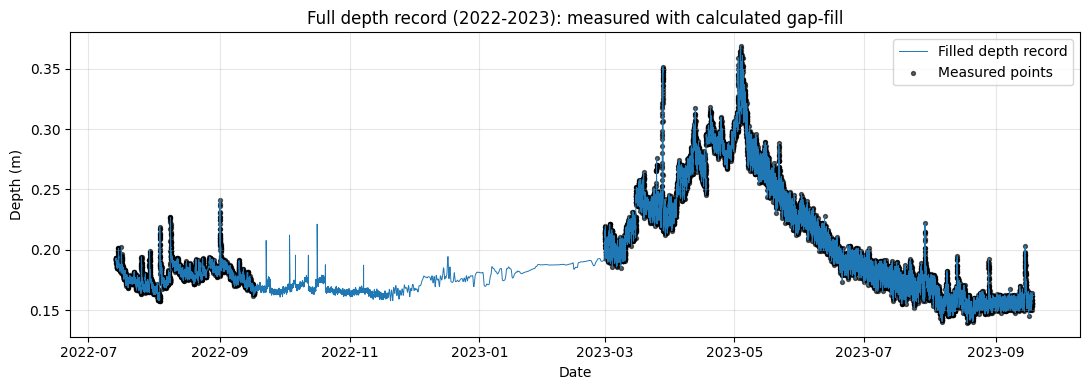

In [50]:
# Build a full depth record for 2022-2023 by filling measured gaps with calculated depth
full_depth = (
    discharge[["stage_m"]]
    .rename(columns={"stage_m": "calculated_depth"})
    .join(measured_p3, how="left")
)

# Use measured depth when available; otherwise fill with calculated depth
full_depth["depth_filled_m"] = full_depth["measured_p3"].combine_first(full_depth["calculated_depth"])

# Keep only 2022-2023 record
full_depth = full_depth.loc["2022-01-01":"2023-12-31"]

# Optional source flag to track where each value came from
full_depth["depth_source"] = np.where(full_depth["measured_p3"].notna(), "measured_p3", "calculated")

print(f"Total timestamps in full record: {len(full_depth)}")
print(f"Measured values used: {(full_depth['depth_source'] == 'measured_p3').sum()}")
print(f"Calculated gap-fill values used: {(full_depth['depth_source'] == 'calculated').sum()}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(full_depth.index, full_depth["depth_filled_m"], color="tab:blue", linewidth=0.7, label="Filled depth record")
ax.scatter(
    full_depth.index[full_depth["depth_source"] == "measured_p3"],
    full_depth.loc[full_depth["depth_source"] == "measured_p3", "depth_filled_m"],
    color="black",
    s=8,
    alpha=0.6,
    label="Measured points",
)
ax.set_xlabel("Date")
ax.set_ylabel("Depth (m)")
ax.set_title("Full depth record (2022-2023): measured with calculated gap-fill")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Calculating Shear Stress

Functions

In [ ]:
def get_hydraulic_radius(X, Y, WSE):
    wet_areas = []
    wet_perimeters = []
    poly_x = []
    poly_y = []

    # Loop through the points of the cross-section to find wet polygon
    for i in range(len(X) - 1):
        y1, y2 = Y[i], Y[i+1]
        x1, x2 = X[i], X[i+1]

        # First, checking if we enter the water
        if (y1 >= WSE and y2 < WSE):
            # Linear interpolation to find the intersection point
            x_int1 = x1 + (WSE - y1) * (x2 - x1) / (y2 - y1)
            poly_x.append(x_int1)
            poly_y.append(WSE)

        # If not, we check if the first point is below the WSE
        if (y1 < WSE):
            poly_x.append(x1)
            poly_y.append(y1)

        # Then, we check if we go out of the water. If we did, we calculate the area and store it
        if (y1 < WSE and y2 >= WSE):
            # Linear interpolation to find the intersection point
            x_int2 = x1 + (WSE - y1) * (x2 - x1) / (y2 - y1)
            poly_x.append(x_int2)
            poly_y.append(WSE)

            # Closing the polygon
            if len(poly_x) > 0:
                poly_x.append(poly_x[0])
                poly_y.append(poly_y[0])

            # Calculating the area
            tempCalc1 = 0.5 * np.abs(np.dot(poly_x, np.roll(poly_y, 1)) - np.dot(poly_y, np.roll(poly_x, 1)))
            wet_areas.append(tempCalc1)

            # Calculating the wet perimeter
            distances = np.sqrt(np.diff(poly_x)**2 + np.diff(poly_y)**2)
            wet_perimeters.append(np.sum(distances[:-1]))

            # Resetting the polygon
            poly_x = []
            poly_y = []

    # return hydraulic radius, wet area, wet perimeter
    tempCalc1 = np.sum(wet_areas)
    tempCalc2 = np.sum(wet_perimeters)
    # check if tempCalc2 is zero to avoid division by zero
    if tempCalc2 == 0:
        hydraulic_radius = float('nan')
    else:
        hydraulic_radius = tempCalc1 / tempCalc2

    return hydraulic_radius

def calculate_hydraulic_radius(topography_df, depth_timeseries, depth_location, depth_column=None):
    X = topography_df['distance'].values
    Z = topography_df['elevation'].values

    if isinstance(depth_timeseries, pd.Series):
        depth = depth_timeseries.values
        times = depth_timeseries.index
    else:
        if depth_column is None:
            if 'depth' in depth_timeseries.columns:
                depth_column = 'depth'
            elif len(depth_timeseries.columns) == 1:
                depth_column = depth_timeseries.columns[0]
            else:
                raise KeyError(
                    "Could not determine depth column automatically. "
                    f"Available columns: {list(depth_timeseries.columns)}"
                )

        depth = depth_timeseries[depth_column].values
        times = depth_timeseries.index

    # find the riverbed elevation at the depth measurement location
    riverbed_elevation_at_depth_location = np.interp(depth_location, X, Z)

    hyd_rad = []

    # loop over each time step and calculate hydraulic radius
    for d in depth:
        wse = riverbed_elevation_at_depth_location + d  # wse at this time step
        hydraulic_radius_calc = get_hydraulic_radius(X, Z, wse)  # calculate hydraulic radius
        hyd_rad.append(hydraulic_radius_calc)

    # create a DataFrame with time and hydraulic radius for each time step
    hydraulic_radius_timeseries = pd.DataFrame({
        'time': times,
        'hydraulic_radius': hyd_rad
    }).set_index('time')

    return hydraulic_radius_timeseries

Hydraulic Radius

In [37]:
P3_topo = pd.read_csv('../XS_topo/P3_topo.csv')
P3_hyd_rad = calculate_hydraulic_radius(P3_topo, full_depth, 0.6, depth_column='depth_filled_m')

P3_hyd_rad.head()

,hydraulic_radius
time,
2022-07-14 00:00:00,0.071158
2022-07-14 00:15:00,0.070671
2022-07-14 00:30:00,0.071158
2022-07-14 00:45:00,0.070671
2022-07-14 01:00:00,0.070995


In [52]:
lajara.merge(P3_hyd_rad, left_index=True, right_index=True, how='inner').tail()

,discharge,stage_m,hydraulic_radius
timestamp,,,
2023-09-18 22:45:00,0.00525,0.16225,0.067186
2023-09-18 23:00:00,0.00525,0.16225,0.067186
2023-09-18 23:15:00,0.00525,0.16225,0.067186
2023-09-18 23:30:00,0.00525,0.16225,0.067186
2023-09-18 23:45:00,0.00525,0.16225,0.067186


#### Shear Stress
$\tau = g \rho s R$

In [58]:
# assigning the other variables
rho = 1000  # density of water in kg/m^3
g = 9.81  # acceleration due to gravity in m/s^2
s = 0.0945 # reach slope in m/m

shear_stress = P3_hyd_rad.copy()
shear_stress['shear_stress'] = rho * g * s * P3_hyd_rad['hydraulic_radius']
lajara['shear_stress'] = rho * g * s * lajara['stage_m']

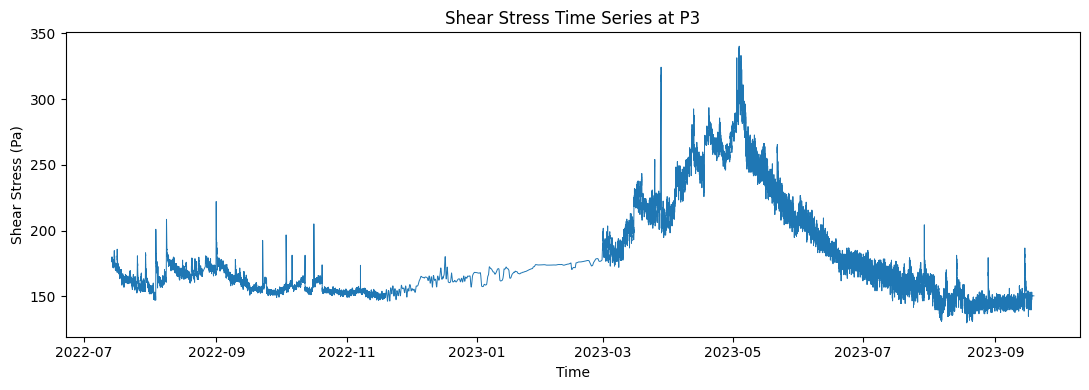

In [59]:
# plot the shear stress time series
plt.figure(figsize=(11, 4))
plt.plot(lajara.index, lajara['shear_stress'], color='tab:blue', linewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Shear Stress (Pa)')
plt.title('Shear Stress Time Series at P3')
plt.tight_layout()
plt.show()